In [1]:
import sys
sys.path.insert(0, '..')

from biomodelml import Experiment
from biomodelml.variants import (
    ResizedSSIMMultiScaleVariant,
    UnrestrictedSSIMVariant,
    SmithWatermanVariant,
    NeedlemanWunschVariant,
)
from biomodelml.matrices import build_matrix
from biomodelml.sanitize import convert_and_remove_unrelated_sequences

from pathlib import Path
from Bio import SeqIO
import matplotlib.pyplot as plt
import numpy as np

2026-02-03 14:00:46.011732: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-03 14:00:46.540038: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-03 14:00:48.466214: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Verificar Dados Disponíveis

In [2]:
data_dir = Path('../data')
fasta_files = list(data_dir.glob('*.fasta'))
print(f"Arquivos FASTA encontrados: {len(fasta_files)}\n")
for f in fasta_files:
    print(f"  - {f.name}")

Arquivos FASTA encontrados: 7

  - orthologs_neuroglobin.fasta
  - orthologs_cytoglobin.fasta
  - indelible.fasta
  - orthologs_hemoglobin_beta.fasta
  - orthologs_androglobin.fasta
  - example_sequences.fasta
  - orthologs_myoglobin.fasta


## 2. Carregar e Examinar Sequências de Exemplo

In [3]:
# Usar o arquivo de exemplo simples
example_file = data_dir / 'example_sequences.fasta'

if example_file.exists():
    sequences = list(SeqIO.parse(example_file, 'fasta'))
    print(f"Número de sequências: {len(sequences)}\n")
    for i, seq in enumerate(sequences, 1):
        print(f"Sequência {i}: {seq.id}")
        print(f"  Tamanho: {len(seq.seq)} bp")
        print(f"  Sequência: {seq.seq}\n")
else:
    # Usar um dos arquivos de ortólogos
    ortho_file = data_dir / 'orthologs_neuroglobin.fasta'
    if ortho_file.exists():
        sequences = list(SeqIO.parse(ortho_file, 'fasta'))
        print(f"Usando {ortho_file.name}")
        print(f"Número de sequências: {len(sequences)}\n")
        for i, seq in enumerate(sequences[:5], 1):  # Mostrar apenas 5
            print(f"Sequência {i}: {seq.id}")
            print(f"  Tamanho: {len(seq.seq)} bp\n")

Número de sequências: 3

Sequência 1: example_seq1
  Tamanho: 25 bp
  Sequência: ATGCGATCGATCGATCGATCGATCG

Sequência 2: example_seq2
  Tamanho: 25 bp
  Sequência: ATGCGATCGAACGATCGATCGATCG

Sequência 3: example_seq3
  Tamanho: 25 bp
  Sequência: ATGCGATCGATCGTTCGATCGATCG



## 3. Gerar Matriz de Auto-Comparação

Demonstrar a criação de matrizes RGB para comparação de sequências.

In [4]:
# Pegar a primeira sequência
seq1 = sequences[0].seq
seq2 = sequences[1].seq if len(sequences) > 1 else seq1

# Gerar matriz
matrix = build_matrix(seq1, seq2, max_window=255, seq_type='N')

print(f"Forma da matriz: {matrix.shape}")
print(f"Tipo: {matrix.dtype}")
print(f"Valores min/max: {matrix.min():.2f} / {matrix.max():.2f}")

Forma da matriz: (25, 25, 3)
Tipo: uint8
Valores min/max: 0.00 / 255.00


### Visualizar os 3 Canais RGB

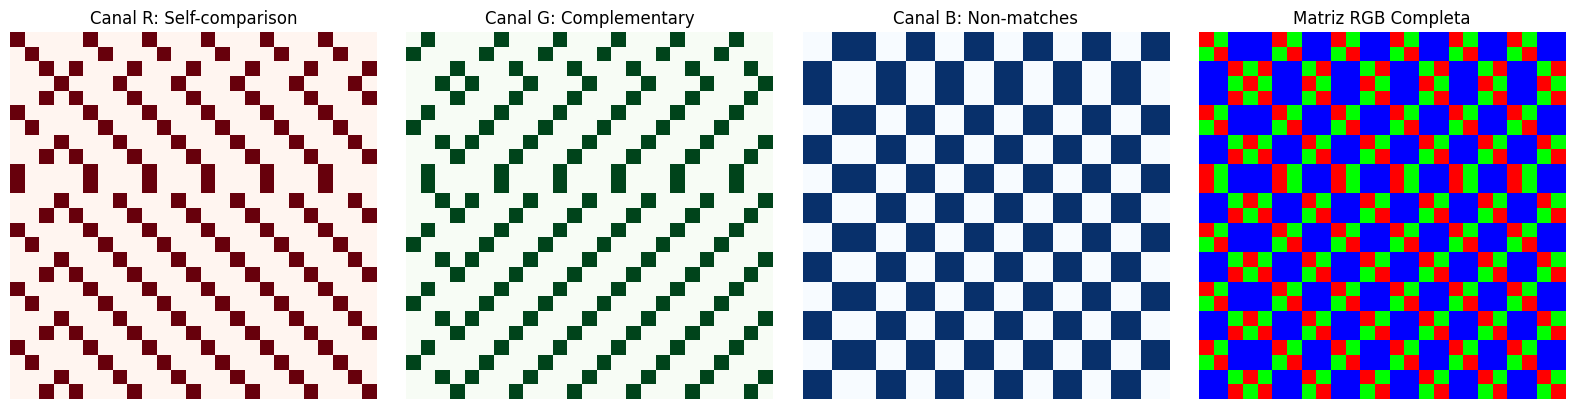

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Canal R: Self-comparison
axes[0].imshow(matrix[:, :, 0], cmap='Reds')
axes[0].set_title('Canal R: Self-comparison')
axes[0].axis('off')

# Canal G: Complementary
axes[1].imshow(matrix[:, :, 1], cmap='Greens')
axes[1].set_title('Canal G: Complementary')
axes[1].axis('off')

# Canal B: Non-matches
axes[2].imshow(matrix[:, :, 2], cmap='Blues')
axes[2].set_title('Canal B: Non-matches')
axes[2].axis('off')

# Matriz RGB completa
# Normalizar para visualização
matrix_norm = matrix / matrix.max() if matrix.max() > 0 else matrix
axes[3].imshow(matrix_norm)
axes[3].set_title('Matriz RGB Completa')
axes[3].axis('off')

plt.tight_layout()
plt.show()

## 4. Testar Sanitização de Sequências

Demonstrar a limpeza e validação de sequências.

In [6]:
# Escolher um arquivo para sanitizar
test_file = data_dir / 'orthologs_myoglobin.fasta'

if test_file.exists():
    # Sanitizar para nucleotídeos
    # A função cria automaticamente o arquivo com extensão .N.sanitized
    convert_and_remove_unrelated_sequences(
        str(test_file),
        'N'
    )
    
    # Verificar resultado
    output_file = Path(f"{test_file}.N.sanitized")
    if output_file.exists():
        sanitized = list(SeqIO.parse(output_file, 'fasta'))
        print(f"\nArquivo original: {test_file.name}")
        print(f"Sequências sanitizadas: {len(sanitized)}")
        print(f"Arquivo gerado: {output_file.name}")
        # Limpar arquivo de teste
        output_file.unlink()
        print(f"Arquivo de teste removido.")
else:
    print(f"Arquivo {test_file.name} não encontrado")

writing 15 sequences

Arquivo original: orthologs_myoglobin.fasta
Sequências sanitizadas: 15
Arquivo gerado: orthologs_myoglobin.fasta.N.sanitized
Arquivo de teste removido.


## 5. Comparar Algoritmos de Similaridade

Testar diferentes algoritmos com um pequeno conjunto de sequências.

In [7]:
# Usar arquivo sanitizado se existir, senão criar temporário
test_input = data_dir / 'orthologs_neuroglobin.fasta.N.sanitized'

if not test_input.exists():
    # Criar arquivo temporário com poucas sequências
    test_input = data_dir / 'temp_test.fasta'
    with open(test_input, 'w') as f:
        for i, seq in enumerate(sequences[:3], 1):
            f.write(f">seq{i}\n{seq.seq}\n")

print(f"Arquivo de teste: {test_input.name}")
test_seqs = list(SeqIO.parse(test_input, 'fasta'))
print(f"Sequências: {len(test_seqs)}")

Arquivo de teste: orthologs_neuroglobin.fasta.N.sanitized
Sequências: 15


In [8]:
# Testar com algoritmos tradicionais (mais rápidos)
output_dir = Path('../output_test')
output_dir.mkdir(exist_ok=True)

print("Testando algoritmos...\n")

# Criar e executar experimento para SW e NW
experiment = Experiment(
    output_dir,
    SmithWatermanVariant(str(test_input), 'N'),
    NeedlemanWunschVariant(str(test_input), 'N'),
)
experiment.run()
sw_tree_struct = experiment._trees[0]
nw_tree_struct = experiment._trees[1]

print("1. Smith-Waterman (Local Alignment)")
print(f"   Matriz de distâncias: {sw_tree_struct.distances.matrix.shape}")
print(f"   Valores: min={sw_tree_struct.distances.matrix.min():.4f}, max={sw_tree_struct.distances.matrix.max():.4f}\n")

print("2. Needleman-Wunsch (Global Alignment)")
print(f"   Matriz de distâncias: {nw_tree_struct.distances.matrix.shape}")
print(f"   Valores: min={nw_tree_struct.distances.matrix.min():.4f}, max={nw_tree_struct.distances.matrix.max():.4f}\n")

Testando algoritmos...

1. Smith-Waterman (Local Alignment)
   Matriz de distâncias: (15, 15)
   Valores: min=0.0000, max=0.4741

2. Needleman-Wunsch (Global Alignment)
   Matriz de distâncias: (15, 15)
   Valores: min=0.0000, max=0.5925



### Visualizar Matrizes de Distância

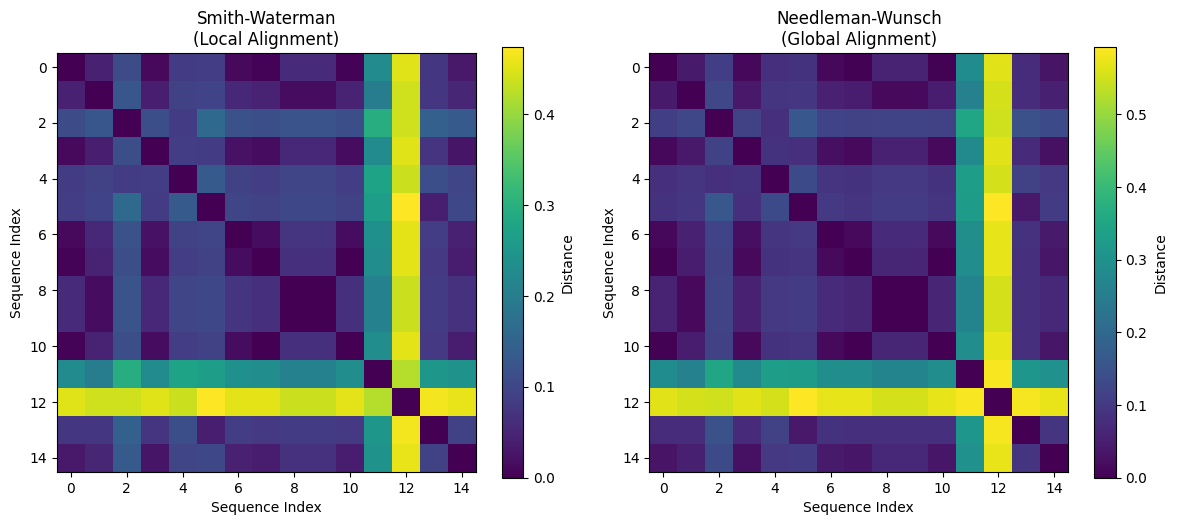

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Smith-Waterman
im1 = axes[0].imshow(sw_tree_struct.distances.matrix, cmap='viridis')
axes[0].set_title('Smith-Waterman\n(Local Alignment)')
axes[0].set_xlabel('Sequence Index')
axes[0].set_ylabel('Sequence Index')
plt.colorbar(im1, ax=axes[0], label='Distance')

# Needleman-Wunsch
im2 = axes[1].imshow(nw_tree_struct.distances.matrix, cmap='viridis')
axes[1].set_title('Needleman-Wunsch\n(Global Alignment)')
axes[1].set_xlabel('Sequence Index')
axes[1].set_ylabel('Sequence Index')
plt.colorbar(im2, ax=axes[1], label='Distance')

plt.tight_layout()
plt.show()

## 6. Construir Árvore Filogenética

Gerar dendrograma a partir das distâncias calculadas.

In [10]:
# Gerar árvore com Smith-Waterman
sw_tree = sw_tree_struct.tree
print("Árvore Filogenética (Smith-Waterman):")
print(sw_tree)
newick_path = output_dir / f"{sw_tree_struct.name}.nw"
with open(newick_path, 'w') as f:
    f.write(str(sw_tree))
print(f"Formato Newick salvo em: {newick_path}")

Árvore Filogenética (Smith-Waterman):
((10:0.0,7:0.0):0.003947367891669273,0:4.656612873077393e-10,(((14:0.0226356890052557,((13:0.012408624403178692,5:0.027065059170126915):0.03865131735801697,(((12:0.31630629301071167,11:0.10513894259929657):0.08772173523902893,(4:0.027970487251877785,2:0.05492424964904785):0.021621447056531906):0.010679034516215324,((9:0.0,8:0.0):0.013791413977742195,1:0.001998059218749404):0.01580122299492359):0.004194080829620361):0.01394599862396717):0.0012746714055538177,3:0.0043996721506118774):0.007391035556793213,6:0.011687912046909332):0.00015419325791299343):0.0;
Formato Newick salvo em: ../output_test/Local with Smith–Waterman.nw


Árvore visualizada salva em: ../output_test/tree_test.png


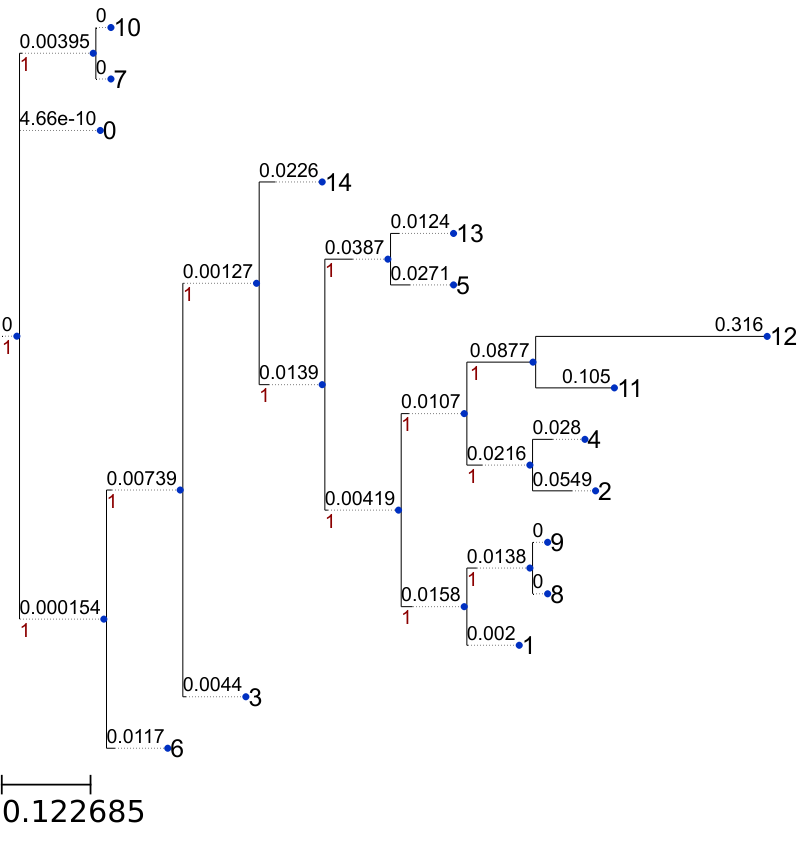

In [11]:
# Visualizar a árvore usando ete3
try:
    import os
    # Configurar para renderização offscreen
    os.environ['QT_QPA_PLATFORM'] = 'offscreen'
    
    from ete3 import Tree
    from ete3.treeview import TreeStyle, NodeStyle
    
    tree = Tree(str(newick_path))
    
    # Estilo
    ts = TreeStyle()
    ts.show_leaf_name = True
    ts.show_branch_length = True
    ts.show_branch_support = True
    
    # Renderizar
    output_png = str(output_dir / "tree_test.png")
    tree.render(output_png, w=800, tree_style=ts)
    print(f"Árvore visualizada salva em: {output_dir}/tree_test.png")
    
    # Mostrar no notebook (se possível)
    from IPython.display import Image
    if os.path.exists(output_png):
        display(Image(filename=output_png))
    
except ImportError:
    print("ete3 não instalado. Instale com: pip install ete3")
except Exception as e:
    print(f"Erro ao visualizar árvore: {e}")
    import traceback
    traceback.print_exc()

## 7. Experimento Completo

Executar experimento com múltiplos algoritmos usando a API de alto nível.

Executando experimento com 2 algoritmos...
Local with Smith–Waterman done!
Global with Needleman-Wunsch done!

Experimento concluído!
Resultados salvos em: ../output_test/

Treees geradas:

Global with Needleman-Wunsch:


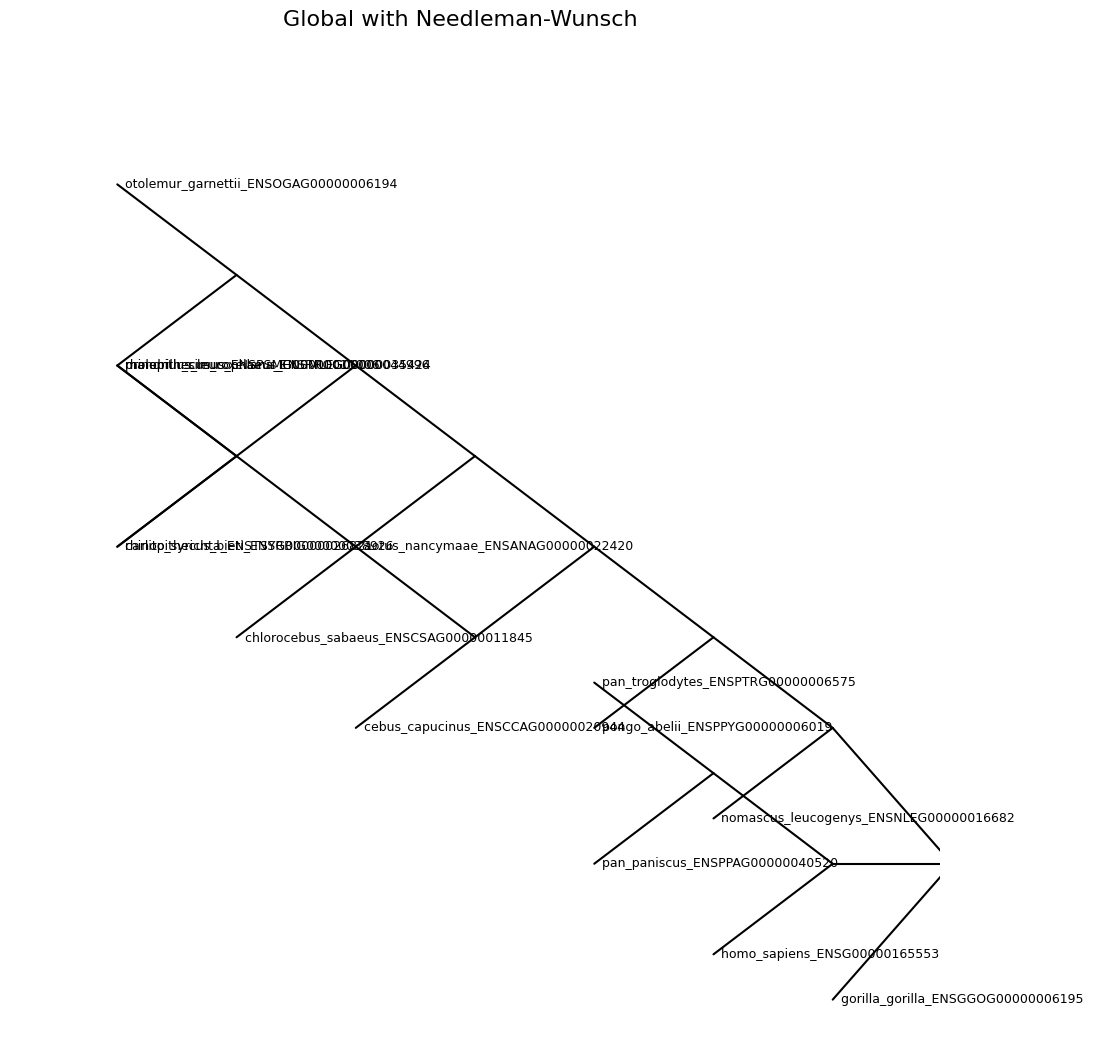


Local with Smith–Waterman:


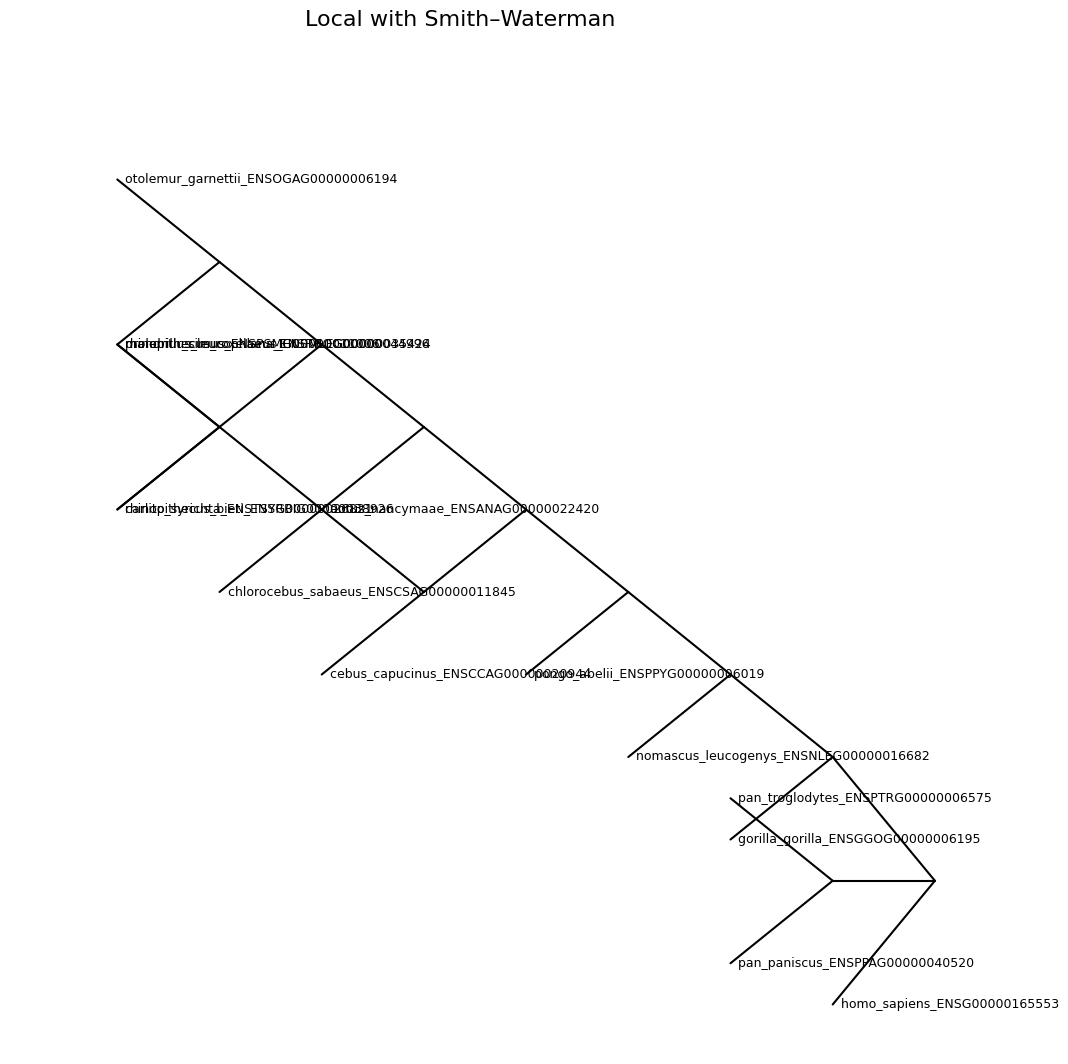


tree_test:


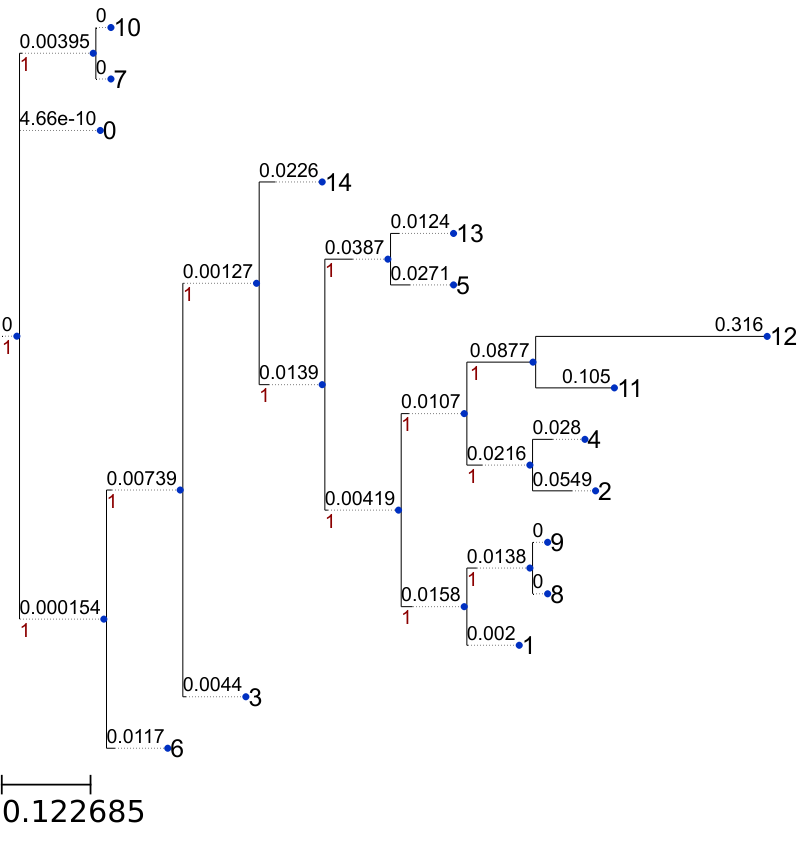

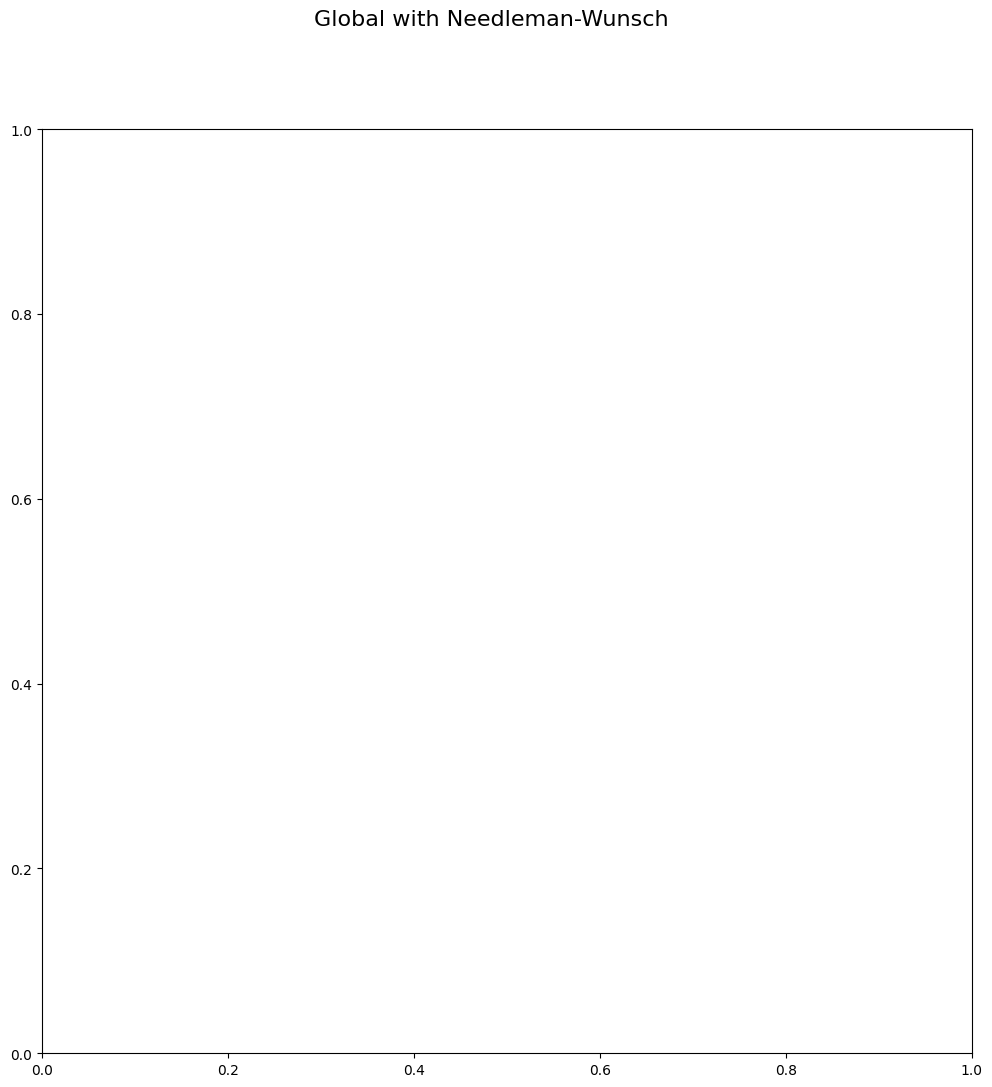

In [33]:
# Criar experimento com múltiplos algoritmos
from IPython.display import Image as IPImage, display

experiment = Experiment(
    output_dir,
    SmithWatermanVariant(str(test_input), 'N'),
    NeedlemanWunschVariant(str(test_input), 'N'),
)

print("Executando experimento com 2 algoritmos...")
experiment.run_and_save()
print("\nExperimento concluído!")
print(f"Resultados salvos em: {output_dir}/")

# Display the generated tree visualizations
print("\nTreees geradas:")
for png_file in sorted(output_dir.glob('*.png')):
    print(f"\n{png_file.stem}:")
    display(IPImage(filename=str(png_file)))

In [14]:
# Listar arquivos gerados
result_files = list(output_dir.glob('*'))
print(f"Arquivos gerados ({len(result_files)}):")
for f in sorted(result_files):
    print(f"  - {f.name}")

Arquivos gerados (7):
  - Global with Needleman-Wunsch.csv
  - Global with Needleman-Wunsch.nw
  - Global with Needleman-Wunsch.png
  - Local with Smith–Waterman.csv
  - Local with Smith–Waterman.nw
  - Local with Smith–Waterman.png
  - tree_test.png


## 8. Limpeza

Remover arquivos temporários de teste.

In [37]:
import shutil

# Limpar diretório de saída
if output_dir.exists():
    shutil.rmtree(output_dir)
    print(f"Removido: {output_dir}")

# Remover arquivo temporário se criado
temp_file = data_dir / 'temp_test.fasta'
if temp_file.exists():
    temp_file.unlink()
    print(f"Removido: {temp_file}")

print("\nLimpeza concluída!")

Removido: ../output_test

Limpeza concluída!


## Resumo

Este notebook demonstrou:

1. ✅ Carregamento de sequências FASTA
2. ✅ Geração de matrizes RGB de auto-comparação
3. ✅ Visualização dos canais da matriz
4. ✅ Sanitização de sequências
5. ✅ Comparação com algoritmos tradicionais (SW, NW)
6. ✅ Construção de árvores filogenéticas
7. ✅ Uso da API de experimentos

Para testes mais avançados com algoritmos SSIM, certifique-se de ter TensorFlow instalado:
```bash
pip install biomodelml[full]
```